In [3]:
pip install numpy pandas opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
print(np.__version__)

2.2.6


In [1]:
import os
import pathlib

In [4]:
import pandas as df
import cv2
import matplotlib.pyplot as plt

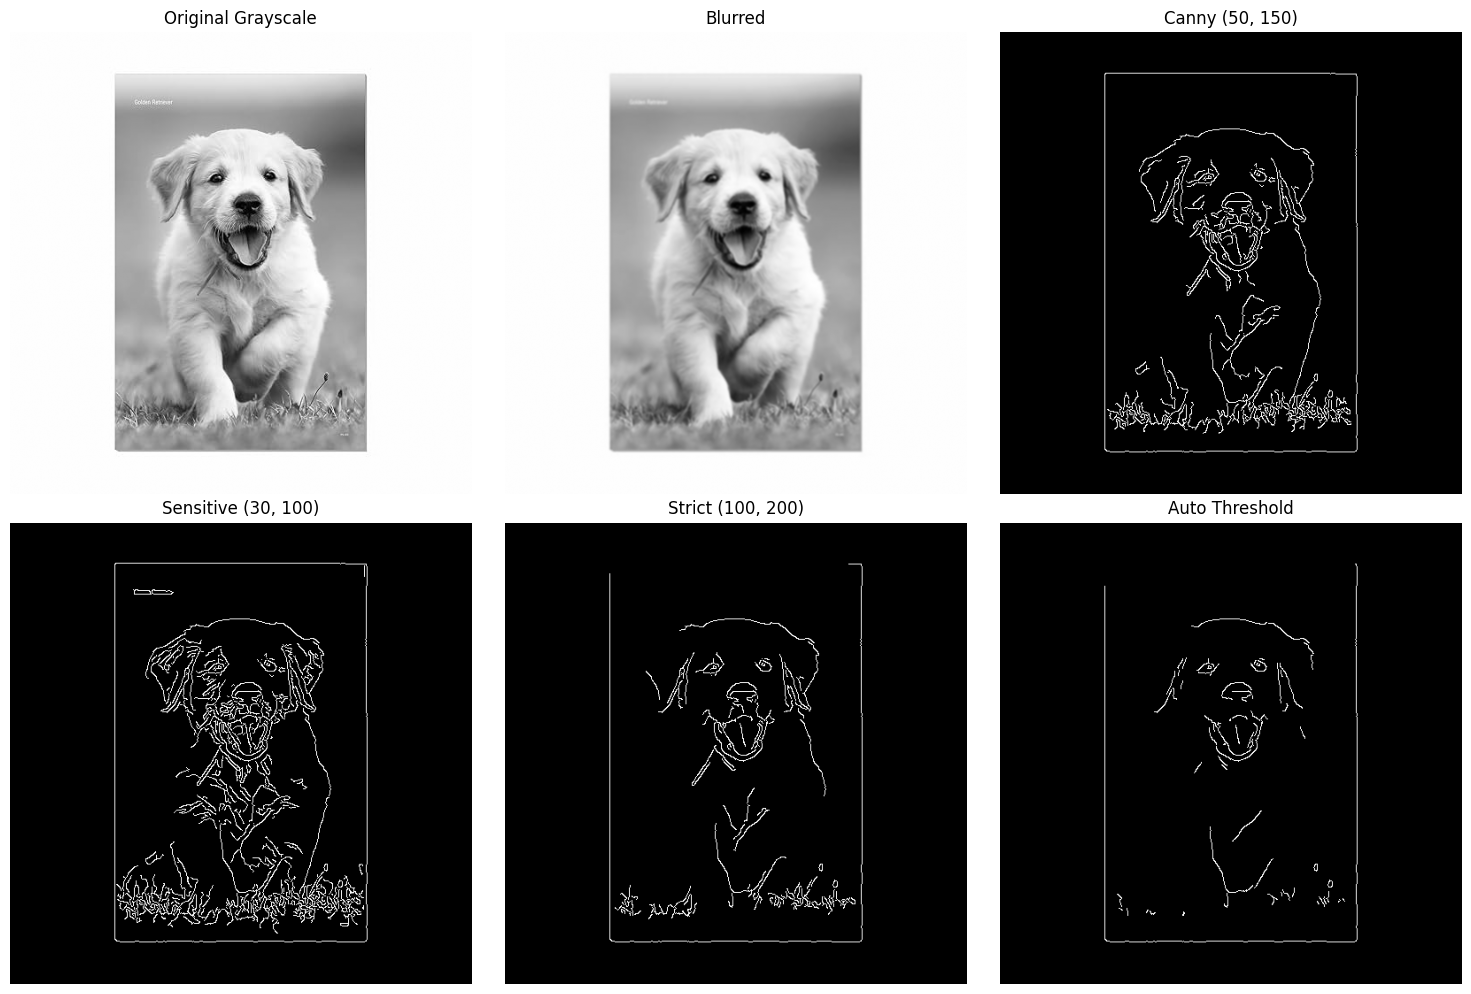

In [5]:
image = cv2.imread('dog.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur first (reduces noise)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Canny edge detection
edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
# threshold1 = lower threshold for weak edges
# threshold2 = upper threshold for strong edges
# Edge pixels between thresholds are included only if connected to strong edges

# Try different thresholds
edges_sensitive = cv2.Canny(blurred, 30, 100)   # More edges
edges_strict = cv2.Canny(blurred, 100, 200)     # Fewer edges
edges_auto = cv2.Canny(blurred, 0, 255)         # Auto thresholds

# Automatic threshold calculation (Otsu's method inspiration)
def auto_canny(image, sigma=0.33):
    """Automatically determine Canny thresholds"""
    median_val = np.median(image)
    lower = int(max(0, (1.0 - sigma) * median_val))
    upper = int(min(255, (1.0 + sigma) * median_val))
    return cv2.Canny(image, lower, upper)

edges_auto_calc = auto_canny(blurred)

# Display results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Original Grayscale')

axes[1].imshow(blurred, cmap='gray')
axes[1].set_title('Blurred')

axes[2].imshow(edges, cmap='gray')
axes[2].set_title('Canny (50, 150)')

axes[3].imshow(edges_sensitive, cmap='gray')
axes[3].set_title('Sensitive (30, 100)')

axes[4].imshow(edges_strict, cmap='gray')
axes[4].set_title('Strict (100, 200)')

axes[5].imshow(edges_auto_calc, cmap='gray')
axes[5].set_title('Auto Threshold')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Created output folder: edge_results
Found 1 images
[1/1] Processing: dog.jpg


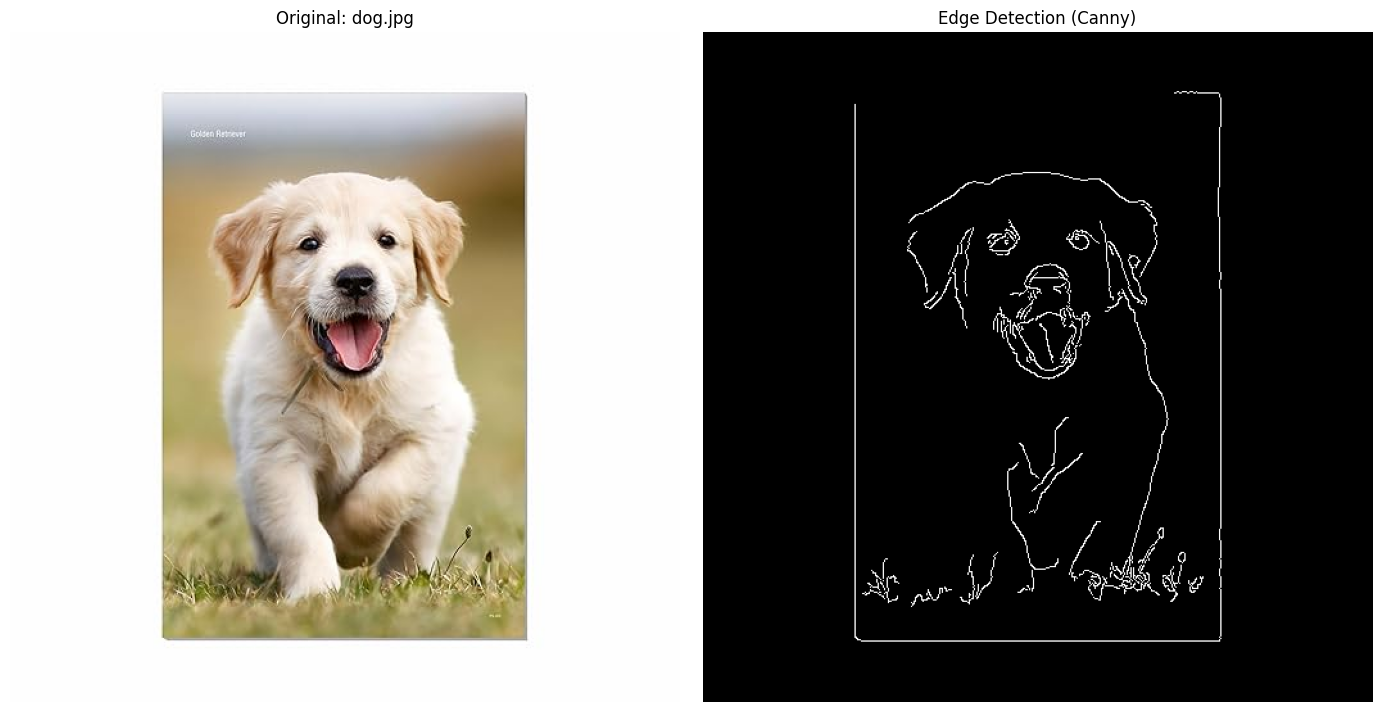

  Saved: edge_results\edges_dog.png



In [ ]:
import os
from pathlib import Path

def detect_edges(image_path, low_threshold=50, high_threshold=150, blur_kernel=5):
    """
    Apply Canny edge detection to an image with preprocessing.
    
    Args:
        image_path: Path to input image
        low_threshold: Lower threshold for Canny
        high_threshold: Upper threshold for Canny
        blur_kernel: Gaussian blur kernel size (must be odd)
    
    Returns:
        original_image_rgb, edges_image
    """
    # Read image
    image = cv2.imread(image_path)
    
    if image is None:
        print(f'Error: Could not load {image_path}')
        return None, None
    
    # Convert to RGB for display
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (blur_kernel, blur_kernel), 0)
    #blurred = cv2.bilateralFilter(gray,9,75,75)
    
    # Apply Canny edge detection
    edges = cv2.Canny(blurred, low_threshold, high_threshold)
    
    return image_rgb, edges


def process_image_folder(folder_path, output_folder=None, 
                         low_threshold=50, high_threshold=150):
    """
    Process all images in a folder and display/save edge detection results.
    
    Args:
        folder_path: Path to folder containing images
        output_folder: Optional path to save edge-detected images
        low_threshold: Canny lower threshold
        high_threshold: Canny upper threshold
    """
    # Create output folder if specified
    if output_folder:
        Path(output_folder).mkdir(parents=True, exist_ok=True)
        print(f"Created output folder: {output_folder}")
    
    # Get list of image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
    image_files = [
        f for f in os.listdir(folder_path)
        if Path(f).suffix.lower() in image_extensions
    ]
    
    if not image_files:
        print(f"No images found in {folder_path}")
        return
    
    print(f'Found {len(image_files)} images')
    
    # Process each image
    for idx, img_file in enumerate(image_files, 1):
        img_path = os.path.join(folder_path, img_file)
        print(f'[{idx}/{len(image_files)}] Processing: {img_file}')
        
        # Detect edges
        original, edges = detect_edges(img_path, low_threshold, high_threshold)
        
        if original is None:
            continue
        
        # Create side-by-side display
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        
        axes[0].imshow(original)
        axes[0].set_title(f'Original: {img_file}')
        axes[0].axis('off')
        
        axes[1].imshow(edges, cmap='gray')
        axes[1].set_title(f'Edge Detection (Canny)')
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Save edge image if output folder specified
        if output_folder:
            output_name = f'edges_{Path(img_file).stem}.png'
            output_path = os.path.join(output_folder, output_name)
            cv2.imwrite(output_path, edges)
            print(f'  Saved: {output_path}')
        
        print()  # Empty line for readability


def batch_compare_thresholds(image_path):
    """
    Compare different Canny thresholds on a single image.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error loading {image_path}")
        return
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Different threshold combinations
    thresholds = [
        (30, 100, 'Sensitive'),
        (50, 150, 'Balanced'),
        (100, 200, 'Strict'),
        (0, 255, 'Auto')
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.ravel()
    
    for idx, (low, high, name) in enumerate(thresholds):
        edges = cv2.Canny(blurred, low, high)
        axes[idx].imshow(edges, cmap='gray')
        axes[idx].set_title(f'{name}\n(low={low}, high={high})')
        axes[idx].axis('off')
    
    plt.suptitle(f'Canny Edge Detection - Threshold Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # Process folder
    process_image_folder(
        folder_path='wokwi',
        output_folder='edge_results',
        low_threshold=50,
        high_threshold=150
    )

TASK-1 CV

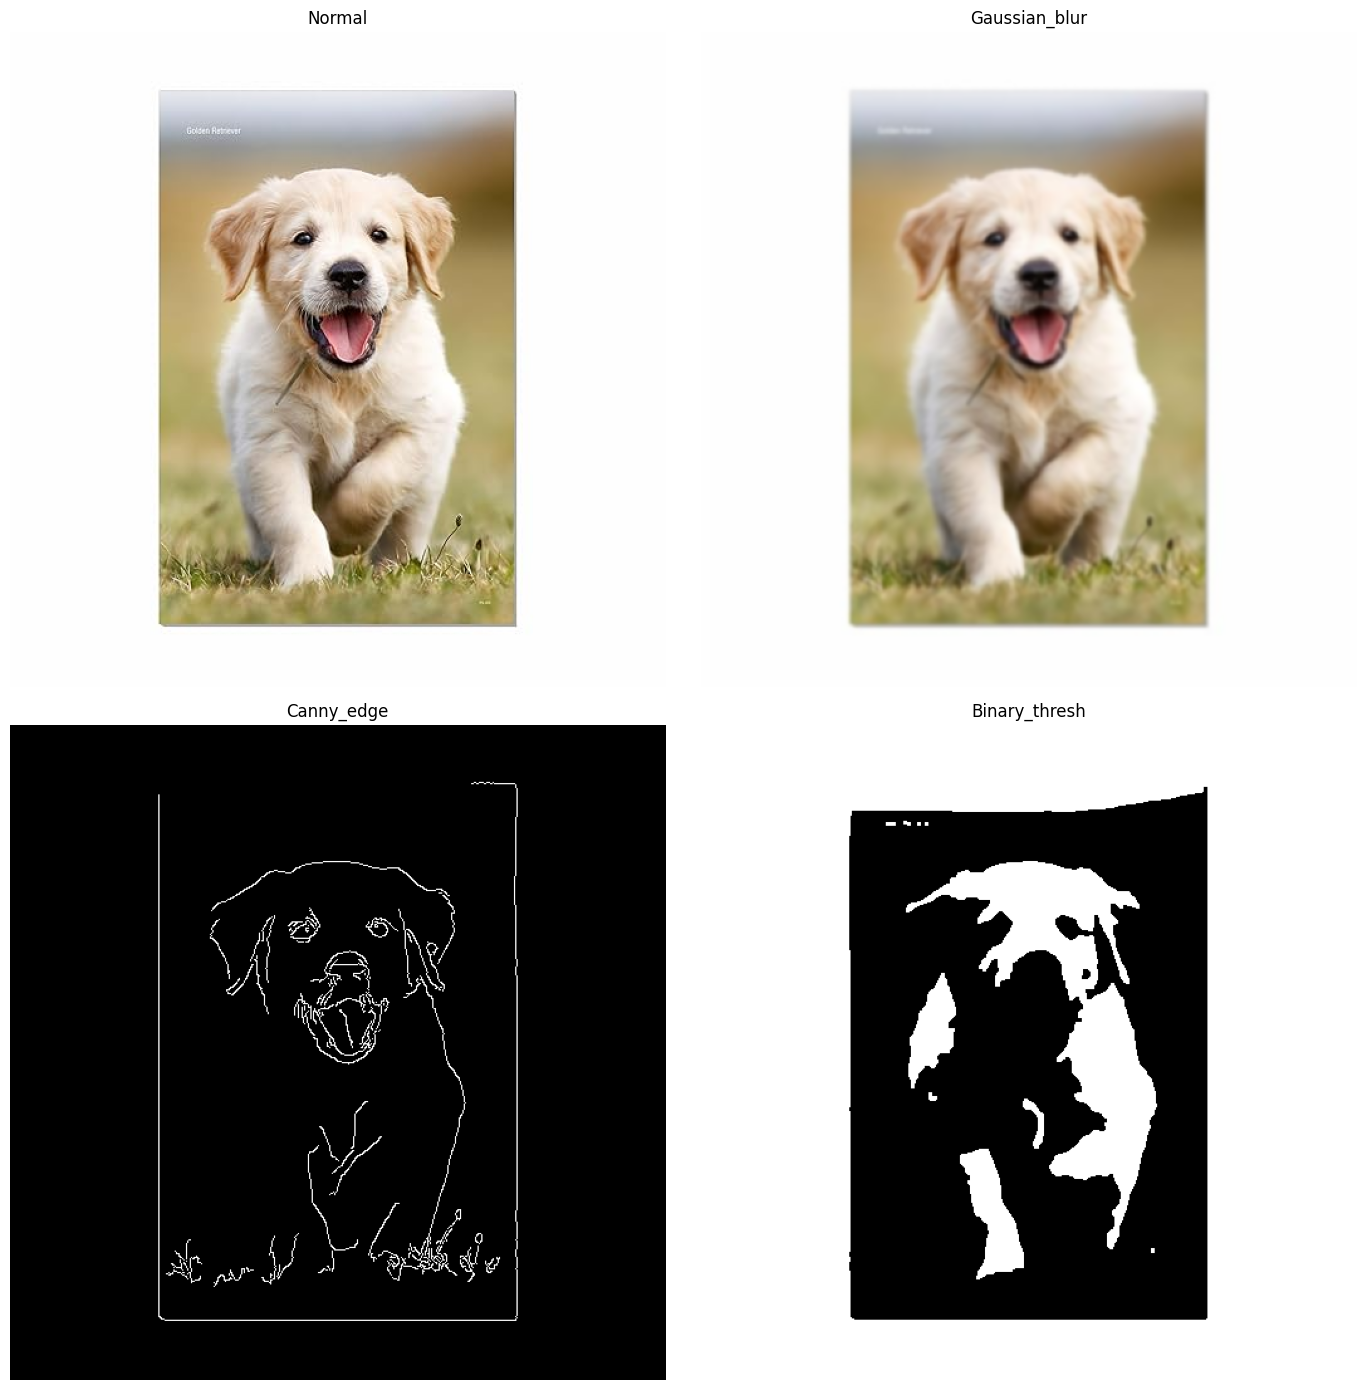

In [ ]:
path = 'dog.jpg'
image  = cv2.imread(path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

gaussian_blurred = cv2.GaussianBlur(image,(7,7),0)

def canny(image_file,low,high) :
    gray = cv2.cvtColor(image_file,cv2.COLOR_RGB2GRAY)
    #gray_blurred = cv2.GaussianBlur(gray,(7,7),0)
    gray_blurred = cv2.bilateralFilter(gray,9,75,75)
    edges = cv2.Canny(gray_blurred,low,high)

    return edges

def binary_thresh(image_file,threshold) :
    gray = cv2.cvtColor(image_file,cv2.COLOR_RGB2GRAY)
    gray_blurred = cv2.GaussianBlur(gray,(5,5),0)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    binary = cv2.threshold(gray_blurred, threshold, 255, cv2.THRESH_BINARY)[1]
    clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

    return clean

def otsu_thresh(image_file) :
    gray = cv2.cvtColor(image_file,cv2.COLOR_RGB2GRAY)
    gray_blurred = cv2.GaussianBlur(gray,(5,5),0)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    binary = cv2.threshold(gray_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    clean = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel)

    return clean

canny_image = canny(image,50,150)

T = np.clip(np.median(gaussian_blurred), 50, 200)
binary_image = binary_thresh(image,T)
#binary_image = otsu_thresh(image)

images = [image,gaussian_blurred,canny_image,binary_image]
titles = ['Normal','Gaussian_blur','Canny_edge','Binary_thresh']
ids = [0,1,2,3]

fig,axes = plt.subplots(2,2,figsize = (14,14))
axes = axes.ravel()
for a,b,c in zip(images,titles,ids) :
    if c == 2 or c== 3 :
        axes[c].imshow(a,cmap = 'gray')
    else :
        axes[c].imshow(a)

    axes[c].set_title(b)
    axes[c].axis('off')

plt.tight_layout()
plt.show()